<a href="https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex%2Fgame-dynamics-dtb/DTB_Game_Ver2/cournot_3d_nonpotential_stochastic_mlp_dtb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3D non-potential Cournot: stochastic neural-DTB with score evolution

## Three-player game setup

For player $i$, let $r_i=\sum_{j\ne i}x_j$. With $b=1$ and $\mu=2$, the
payoff-gradient velocity from the thesis is

$$
b_i(x)=-2x_i+4r_i-4r_i^2.
$$

The stochastic dynamics use three independent Brownian motions with the exact
thesis amplitudes

$$
\sigma_1=\sigma_2=\sigma_3=0.1,
\qquad D=\operatorname{diag}(\sigma_1^2,\sigma_2^2,\sigma_3^2)=0.01I_3.
$$

The initial distribution is uniform on $[0,1]^3$, matching the thesis
non-potential experiment. The five reported reference equilibria are the
origin, $(3/8,3/8,3/8)$, and the three permutations of $(1/2,1/2,0)$.
The origin is unstable and the other four are reported as stable. This
notebook compares stochastic neural-DTB with a matched Euler--Maruyama (EM)
baseline. Both methods start from the same particles and noise amplitudes,
but have independent time grids, stopping conditions, timers, and histories. The reference points are zeros of the deterministic
drift implemented here; they are not point equilibria of the noisy trajectories.

**Execution order:** run Blocks 0–2 once, then run Block 3 (DTB) and Block 4
(EM) in either order. Either method can also run alone. Blocks 5–6 compare
whatever results are available. Re-running a method starts it afresh from
the shared initial cloud and does not change the other result. Re-running
Block 2 clears both results when you change the initial data or game settings.


## Block 0 — Shared repository setup

This notebook reuses `ResidualMLPMap`, `game_dtb_basis_matrices`, and
`map_at` from `run_game_dtb.py`; `count_trainable` from `network.py`;
and `flat_params` plus `jform_solve` from `dtb.py`. Spatial tangent
derivatives and score evolution come from the shared `utility.py`.

In [1]:
# BLOCK 0 — Locate the shared modules locally or clone the requested branch in Colab.
from pathlib import Path
import math
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

MODULE_FILES = ('run_game_dtb.py', 'network.py', 'dtb.py', 'utility.py')
EXPERIMENT_DIR = next(
    (
        folder
        for folder in (Path.cwd(), Path.cwd() / 'DTB_Game_Ver2')
        if all((folder / name).is_file() for name in MODULE_FILES)
    ),
    None,
)

if EXPERIMENT_DIR is None:
    if not Path('/content').is_dir():
        raise FileNotFoundError('Run from the repository root or DTB_Game_Ver2 directory.')
    repo = Path('/content/dtb-colab-experiments')
    if not (repo / '.git').exists():
        subprocess.run([
            'git', 'clone', '--depth', '1', '--branch', 'codex/game-dynamics-dtb',
            'https://github.com/sun-mengwei/dtb-colab-experiments.git', str(repo),
        ], check=True)
    else:
        subprocess.run(['git', '-C', str(repo), 'checkout', 'codex/game-dynamics-dtb'], check=True)
        subprocess.run(['git', '-C', str(repo), 'pull', '--ff-only'], check=True)
    EXPERIMENT_DIR = repo / 'DTB_Game_Ver2'

# Import the existing DTB, network, and map primitives requested for reuse.
sys.path.insert(0, str(EXPERIMENT_DIR.resolve()))
from run_game_dtb import ResidualMLPMap, game_dtb_basis_matrices
from network import count_trainable
from dtb import device, flat_params, jform_solve
from importlib import reload
import utility as stochastic_utility

stochastic_utility = reload(stochastic_utility)
from utility import (
    create_run_directory,
    diagnostics_markdown,
    euler_score_update,
    plot_tangent_diagnostics,
    sample_initial_with_score,
    save_run_data,
    tangent_velocity_spatial_terms,
)

print('Shared module directory:', EXPERIMENT_DIR)

Shared module directory: /content/dtb-colab-experiments/DTB_Game_Ver2


## Block 1 — Shared and method-specific controls

Adjust `DTB_H`, `DTB_T_FINAL`, `EM_H`, and `EM_T_FINAL` independently. Each
final time must lie on its method's grid. Snapshot times are matched afterwards
by physical time; they need not be available on both grids.

Optional `DTB_MAX_ABS_STATE` / `EM_MAX_ABS_STATE` limits stop a method when
any particle coordinate exceeds that magnitude. `None` disables this extra
limit; non-finite states always stop the affected method. No state is clipped.


In [2]:
# BLOCK 1 — Define the three-player game and every editable experiment control.
SAVE_RUN = True  # True creates a uniquely named folder under saved_runs/.
SEED = 2026
EM_SEED = SEED + 10_000

DIM = 3
N_PARTICLES = 2000
DTB_H = 0.005
DTB_T_FINAL = 1.0
EM_H = 0.005
EM_T_FINAL = 1.0
DTB_MAX_ABS_STATE = None  # Optional particle-magnitude stop, e.g. 1e6; never clips.
EM_MAX_ABS_STATE = None
SNAPSHOT_TIMES = (0.0, 0.2, 0.4, 0.6, 0.8, 1.0)

# The paper uses independent noise of amplitude 0.1 in every coordinate.
NOISE_STD = (0.1, 0.1, 0.1)

# "uniform" matches the paper's samples and uses the exact interior score q_0=0.
# "gaussian" and "smoothed_uniform" provide globally smooth analytical scores.
INITIAL_LAW = 'uniform'
GAUSSIAN_MEAN = 0.5
GAUSSIAN_STD = 0.15
UNIFORM_SMOOTHING_STD = 0.02

NN_CHOICE = 'mlp'
NN_ACTIVATION = 'tanh'  # Smooth activation is required by grad(div(u)).
MLP_WIDTH = 32
MLP_DEPTH = 4
BASIS_SIZE = 128
SVD_RTOL = 1e-3
SVD_METHOD = 'svd_gpu'
JACOBIAN_CHUNK = 64
DERIVATIVE_CHUNK = 32
PRINT_EVERY = 20

DTYPE = torch.float32
DEVICE = device()
COURNOT_B = 1.0
COURNOT_MU = 2.0
COORDINATE_PAIRS = ((1, 2),)

# Separate 3D figures use the same view, limits, and displayed particle labels.
PLOT_3D_COLUMNS = 2
PLOT_3D_MAX_POINTS = None  # None shows every particle; otherwise a seeded subset.
PLOT_3D_ELEV = 22.0
PLOT_3D_AZIM = -55.0
PLOT_3D_POINT_SIZE = 2.0
PLOT_3D_ALPHA = 0.35

def game_velocity(x):
    """Three-player non-potential Cournot payoff-gradient field."""
    if x.shape[-1] != DIM:
        raise ValueError(f'Expected states with last dimension {DIM}.')
    rivals = x.sum(dim=-1, keepdim=True) - x
    return -2.0 * COURNOT_B * x + 2.0 * COURNOT_B * COURNOT_MU * rivals * (1.0 - rivals)

KNOWN_EQUILIBRIA = torch.tensor([
    [0.0, 0.0, 0.0],
    [3/8, 3/8, 3/8],
    [1/2, 1/2, 0.0],
    [1/2, 0.0, 1/2],
    [0.0, 1/2, 1/2],
], device=DEVICE, dtype=DTYPE)
EQUILIBRIUM_LABELS = [f'E_{index}' for index in range(len(KNOWN_EQUILIBRIA))]

## Block 2 — Shared initial cloud and run bookkeeping

Both methods copy the same initial particles. This block samples the initial
score as well, but does not construct a neural network or run either method.
Each simulation initializes its own mutable state and random generator.

**Failure handling:** an invalid candidate step is rejected before it enters
the saved history. The result records the failed attempt/time and reason, and
retains every earlier valid state. Numerical overflow and DTB linear-algebra
failures stop only that simulation. Configuration/programming errors are still
raised rather than silently labeled as numerical instability.


In [3]:
# BLOCK 2 — Shared initial data and run bookkeeping; no neural network is required for EM.
if len(NOISE_STD) != DIM:
    raise ValueError('NOISE_STD needs one independent amplitude per player.')
if not SNAPSHOT_TIMES or any(not np.isfinite(t) or t < 0 for t in SNAPSHOT_TIMES):
    raise ValueError('Snapshot times must be nonempty, finite, and nonnegative.')
generator_device = DEVICE.type if DEVICE.type == 'cuda' else 'cpu'
initial_generator = torch.Generator(device=generator_device).manual_seed(SEED)
x_0, q_0, log_density_0 = sample_initial_with_score(
    N_PARTICLES, DIM, law=INITIAL_LAW, device=DEVICE, dtype=DTYPE,
    generator=initial_generator, gaussian_mean=GAUSSIAN_MEAN,
    gaussian_std=GAUSSIAN_STD, smoothing_std=UNIFORM_SMOOTHING_STD,
)
sigma = torch.tensor(NOISE_STD, device=DEVICE, dtype=DTYPE)
diffusion = torch.diag(sigma.square())
equilibrium_residual = float(game_velocity(KNOWN_EQUILIBRIA).norm(dim=1).max())
if equilibrium_residual > 2e-5:
    raise ValueError(f'An equilibrium reference has drift residual {equilibrium_residual:.3e}.')

# Reinitializing shared data clears old results; rerunning one method only replaces that method.
dtb_result = None
em_result = None
CONFIG = {
    'game_dimension': DIM, 'particles': N_PARTICLES,
    'noise_std': list(NOISE_STD), 'diffusion_diagonal': sigma.square().cpu().tolist(),
    'initial_law': INITIAL_LAW, 'gaussian_mean': GAUSSIAN_MEAN,
    'gaussian_std': GAUSSIAN_STD, 'uniform_smoothing_std': UNIFORM_SMOOTHING_STD,
    'seed': SEED, 'device': str(DEVICE), 'dtype': str(DTYPE),
    'cournot_b': COURNOT_B, 'cournot_mu': COURNOT_MU,
    'maximum_equilibrium_residual': equilibrium_residual,
    'equilibria': KNOWN_EQUILIBRIA.cpu().tolist(),
    'equilibrium_labels': EQUILIBRIUM_LABELS,
    'output_root': str(EXPERIMENT_DIR / 'saved_runs'),
    'timing_scope': (
        'Synchronized numerical step attempts including finite-state checks and the first step; '
        'excludes initialization, diagnostics, CPU history copies, printing, plotting, and saving. '
        'Totals include the failed attempt, if any; common-horizon ratios use accepted steps only.'
    ),
}


def synchronize_device():
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize(DEVICE)
    elif DEVICE.type == 'mps':
        torch.mps.synchronize()


def step_count(h, final_time, max_abs_state):
    if not np.isfinite(h) or not np.isfinite(final_time) or h <= 0 or final_time <= 0:
        raise ValueError('The method step size and final time must be finite and positive.')
    count = round(final_time / h)
    if count < 1 or not np.isclose(count * h, final_time, rtol=0, atol=1e-10):
        raise ValueError('The method final time must be an integer multiple of its step size.')
    if max_abs_state is not None and (not np.isfinite(max_abs_state) or max_abs_state <= 0):
        raise ValueError('MAX_ABS_STATE must be None or a finite positive number.')
    return count


def require_finite(**values):
    bad = [name for name, value in values.items() if not bool(torch.isfinite(value).all())]
    if bad:
        raise FloatingPointError('Non-finite ' + ', '.join(bad))


def check_state_limit(particles, limit):
    if limit is not None and float(particles.abs().max()) > limit:
        raise FloatingPointError(f'Particle magnitude exceeded the configured limit {limit:g}')


def new_result(method, h, final_time, max_abs_state):
    count = step_count(h, final_time, max_abs_state)
    require_finite(initial_particles=x_0)
    return {
        'method': method, 'step_size': h, 'requested_final_time': final_time,
        'requested_steps': count, 'max_abs_state': max_abs_state,
        'particles': [x_0.detach().cpu().numpy().copy()], 'step_seconds': [],
        'status': 'completed', 'stop_reason': None, 'failed_step': None, 'failed_time': None,
        'metadata': {},
    }


def mark_stopped(result, step, error):
    result.update(status='stopped', failed_step=step + 1,
                  failed_time=(step + 1) * result['step_size'],
                  stop_reason=f'{type(error).__name__}: {error}')


def finish_result(result, wall_start):
    result['particles'] = np.stack(result['particles'])
    result['step_seconds'] = np.asarray(result['step_seconds'], dtype=float)
    result['completed_steps'] = len(result['particles']) - 1
    result['attempted_steps'] = len(result['step_seconds'])
    result['times'] = np.arange(len(result['particles']), dtype=float) * result['step_size']
    result['last_valid_time'] = float(result['times'][-1])
    result['compute_seconds'] = float(result['step_seconds'].sum())
    result['mean_attempt_seconds'] = (
        float(result['step_seconds'].mean()) if result['attempted_steps'] else None
    )
    synchronize_device()
    result['wall_seconds'] = time.perf_counter() - wall_start
    return result


def report_run(result):
    print(f'{result["method"]}: {result["status"]}; '
          f'{result["completed_steps"]}/{result["requested_steps"]} accepted steps; '
          f'last valid t={result["last_valid_time"]:.6g}; '
          f'compute={result["compute_seconds"]:.6f}s; loop wall={result["wall_seconds"]:.6f}s')
    if result['status'] == 'stopped':
        print(f'  Stopped on attempt {result["failed_step"]}, targeting t={result["failed_time"]:.6g}: '
              f'{result["stop_reason"]}. Earlier valid states remain available.')


print(f'Shared {DIM}D initial cloud: N={N_PARTICLES}, law={INITIAL_LAW}, seed={SEED}')
print(f'Device/dtype: {DEVICE}/{DTYPE}; sigma={NOISE_STD}')
print(f'DTB: h={DTB_H}, T={DTB_T_FINAL}; EM: h={EM_H}, T={EM_T_FINAL}')
print('Run either simulation cell next. Re-run this cell only to reset the shared initial data.')
if INITIAL_LAW == 'uniform':
    print('Uniform-score note: q_0=0 is the interior score; the boundary score is singular.')


Shared 3D initial cloud: N=2000, law=uniform, seed=2026
Device/dtype: cuda/torch.float32; sigma=(0.1, 0.1, 0.1)
DTB: h=0.005, T=1.0; EM: h=0.005, T=1.0
Run either simulation cell next. Re-run this cell only to reset the shared initial data.
Uniform-score note: q_0=0 is the interior score; the boundary score is singular.


## Block 3 — Stochastic DTB tangent and score update

At step $k$, the Fokker--Planck transport target is

$$
g_{k,i}=b(x_{k,i})-\frac12Dq_{k,i}.
$$

The selected neural tangent basis is projected onto this target:

$$
\alpha_k=\arg\min_\alpha\sum_i\|J_{k,i}^S\alpha-g_{k,i}\|_2^2,
\qquad u_k(x)=\partial_{\theta_S}f_{\theta_0}(x)\alpha_k.
$$

Particles and attached scores use the same old-step velocity:

$$
x_i^{k+1}=x_i^k+h u_k(x_i^k),
$$

$$
q_i^{k+1}=q_i^k-h\left([D_xu_k(x_i^k)]^\mathsf{T}q_i^k
+\nabla_x[\nabla_x\!\cdot u_k](x_i^k)\right).
$$

This is the ordinary fixed-basis DTB update: there is no resampling, refit,
score network, or post-run polish step.

This cell runs DTB alone and stores `dtb_result`. Its history and diagnostics
may be shorter than the requested horizon if it stops early. Network setup is
local to this cell, so EM can run even when DTB has not been initialized.

**Timing:** each method times synchronized numerical step attempts, including
finite-state checks. Initialization, diagnostics, history copies, printing,
plotting, and saving are excluded. The first step is included (no warm-up).
Each result also records its own loop wall time. A failed attempt is included
in its total compute time, but excluded from common-horizon comparisons.


In [4]:
# BLOCK 3 — Independent DTB run. This cell never reads or changes em_result.
def run_dtb():
    if NN_ACTIVATION not in {'tanh', 'gelu', 'silu'}:
        raise ValueError('Score evolution requires a twice-differentiable activation.')
    result = new_result('Neural-DTB', DTB_H, DTB_T_FINAL, DTB_MAX_ABS_STATE)
    h = result['step_size']
    # Rebuild the same seeded network and sub-basis on every DTB run.
    torch.manual_seed(SEED)
    if DEVICE.type == 'cuda':
        torch.cuda.manual_seed_all(SEED)
    mlp = ResidualMLPMap(
        dim=DIM, width=MLP_WIDTH, depth=MLP_DEPTH, activation=NN_ACTIVATION,
        dtype=DTYPE, zero_init_output=False,
    ).net.to(DEVICE)
    parameter_count = count_trainable(mlp)
    theta_0, structure, _ = flat_params(mlp)
    mlp.requires_grad_(False)
    if not isinstance(BASIS_SIZE, int) or not 1 <= BASIS_SIZE <= parameter_count:
        raise ValueError(f'BASIS_SIZE must be in [1, {parameter_count}].')
    basis_generator = torch.Generator(device='cpu').manual_seed(SEED)
    selected = torch.randperm(parameter_count, generator=basis_generator)[:BASIS_SIZE]
    selected = selected.sort().values.to(DEVICE)
    result['metadata'] = {
        'network': NN_CHOICE, 'activation': NN_ACTIVATION, 'width': MLP_WIDTH,
        'depth': MLP_DEPTH, 'trainable_parameters': parameter_count, 'basis_size': BASIS_SIZE,
        'selected_parameter_indices': selected.cpu().tolist(), 'svd_rtol': SVD_RTOL,
        'svd_method': SVD_METHOD, 'jacobian_chunk': JACOBIAN_CHUNK,
        'derivative_chunk': DERIVATIVE_CHUNK, 'seed': SEED,
    }
    x_k, q_k, log_density_k = x_0.clone(), q_0.clone(), log_density_0.clone()
    scores = [q_k.detach().cpu().numpy().copy()]
    log_densities = [log_density_k.detach().cpu().numpy().copy()]
    coefficients, records = [], []
    synchronize_device()
    wall_start = time.perf_counter()
    for step in range(result['requested_steps']):
        synchronize_device()
        start = time.perf_counter()
        try:
            drift_k = game_velocity(x_k)
            diffusion_correction = 0.5 * (q_k @ diffusion.T)
            target_k = drift_k - diffusion_correction
            require_finite(target=target_k)
            _, jacobian_tensor, stacked_jacobian = game_dtb_basis_matrices(
                theta_0, selected, x_k, mlp, structure, chunk=JACOBIAN_CHUNK,
            )
            require_finite(tangent_basis=stacked_jacobian)
            alpha_k = jform_solve(
                stacked_jacobian, target_k.reshape(-1), rtol=SVD_RTOL, method=SVD_METHOD,
            )
            require_finite(coefficients=alpha_k)
            tangent_k, grad_u_k, divergence_k, grad_divergence_k = tangent_velocity_spatial_terms(
                theta_0, selected, alpha_k, x_k, mlp, structure, chunk_size=DERIVATIVE_CHUNK,
            )
            q_next, transported_score, score_source = euler_score_update(
                q_k, grad_u_k, grad_divergence_k, h,
            )
            x_next = x_k + h * tangent_k
            log_density_next = log_density_k - h * divergence_k
            require_finite(particles=x_next, score=q_next, log_density=log_density_next)
            check_state_limit(x_next, DTB_MAX_ABS_STATE)
        except (FloatingPointError, torch.linalg.LinAlgError) as error:
            mark_stopped(result, step, error)
        finally:
            synchronize_device()
            result['step_seconds'].append(time.perf_counter() - start)
        if result['status'] == 'stopped':
            break

        # Diagnostics and CPU copies are outside the numerical-step timer.
        # Double-precision norms avoid overflow of diagnostics for large finite states.
        norm = lambda value: float(value.double().norm())
        particle_scale = math.sqrt(N_PARTICLES)
        records.append({
            'time': step * h,
            'relative_projection_error': norm(tangent_k - target_k) / max(norm(target_k), 1e-30),
            'alpha_norm': norm(alpha_k), 'score_rms': norm(q_k) / particle_scale,
            'diffusion_rms': norm(diffusion_correction) / particle_scale,
            'target_rms': norm(target_k) / particle_scale,
            'tangent_rms': norm(tangent_k) / particle_scale,
            'score_transport_rms': norm(transported_score) / particle_scale,
            'score_source_rms': norm(score_source) / particle_scale,
        })
        coefficients.append(alpha_k.detach().cpu().numpy().copy())
        x_k, q_k, log_density_k = x_next.detach(), q_next.detach(), log_density_next.detach()
        result['particles'].append(x_k.cpu().numpy().copy())
        scores.append(q_k.cpu().numpy().copy())
        log_densities.append(log_density_k.cpu().numpy().copy())
        if (step + 1) % PRINT_EVERY == 0 or step in (0, result['requested_steps'] - 1):
            print(f'DTB k={step + 1}/{result["requested_steps"]}, t={(step + 1) * h:.4f}, '
                  f'rel.err={records[-1]["relative_projection_error"]:.3e}, '
                  f'step={result["step_seconds"][-1]:.6f}s')
    result['scores'] = np.stack(scores)
    result['log_density'] = np.stack(log_densities)
    result['coefficients'] = np.stack(coefficients) if coefficients else np.empty((0, BASIS_SIZE))
    result['diagnostics'] = records
    result['solve_times'] = np.asarray([record['time'] for record in records])
    return finish_result(result, wall_start)


dtb_result = run_dtb()
report_run(dtb_result)


/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


DTB k=1/200, t=0.0050, rel.err=4.630e-02, step=7.046184s
DTB k=20/200, t=0.1000, rel.err=1.983e-01, step=1.591740s
DTB k=40/200, t=0.2000, rel.err=2.122e-01, step=2.024667s
DTB k=60/200, t=0.3000, rel.err=3.346e-01, step=1.600460s
DTB k=80/200, t=0.4000, rel.err=3.660e-01, step=1.602951s
DTB k=100/200, t=0.5000, rel.err=3.287e-01, step=1.598460s
DTB k=120/200, t=0.6000, rel.err=3.336e-01, step=2.125842s
DTB k=140/200, t=0.7000, rel.err=6.224e-01, step=1.676281s
DTB k=160/200, t=0.8000, rel.err=6.400e-01, step=1.672198s
DTB k=180/200, t=0.9000, rel.err=6.403e-01, step=1.637236s
DTB k=200/200, t=1.0000, rel.err=6.726e-01, step=2.030626s
Neural-DTB: completed; 200/200 accepted steps; last valid t=1; compute=348.857437s; loop wall=349.068674s


## Block 4 — Independent Euler–Maruyama simulation

Run this cell after Block 2; Block 3 is optional. EM uses its own step size,
horizon, initial-state copy, and freshly seeded Gaussian-noise generator:

$$
x_{k+1}^{\mathrm{EM}}=x_k^{\mathrm{EM}}+h_{\mathrm{EM}}b(x_k^{\mathrm{EM}})
+\sqrt{h_{\mathrm{EM}}}\,\operatorname{diag}(\sigma)\xi_k,
\qquad \xi_k\sim N(0,I_3).
$$

The result is `em_result`; rerunning this cell does not rerun or modify DTB.
A non-finite EM step stops EM while retaining its valid snapshots.


In [5]:
# BLOCK 4 — Independent EM run. Run after shared initialization, with or without DTB.
def run_em():
    result = new_result('Euler--Maruyama', EM_H, EM_T_FINAL, EM_MAX_ABS_STATE)
    h = result['step_size']
    em_k = x_0.clone()
    # A fresh private generator makes reruns reproducible, regardless of DTB execution order.
    generator = torch.Generator(device=generator_device).manual_seed(EM_SEED)
    result['metadata'] = {'seed': EM_SEED}
    synchronize_device()
    wall_start = time.perf_counter()
    for step in range(result['requested_steps']):
        synchronize_device()
        start = time.perf_counter()
        try:
            noise = torch.randn(em_k.shape, device=DEVICE, dtype=DTYPE, generator=generator)
            em_next = em_k + h * game_velocity(em_k) + math.sqrt(h) * sigma * noise
            require_finite(particles=em_next)
            check_state_limit(em_next, EM_MAX_ABS_STATE)
        except FloatingPointError as error:
            mark_stopped(result, step, error)
        finally:
            synchronize_device()
            result['step_seconds'].append(time.perf_counter() - start)
        if result['status'] == 'stopped':
            break
        em_k = em_next.detach()
        result['particles'].append(em_k.cpu().numpy().copy())
        if (step + 1) % PRINT_EVERY == 0 or step in (0, result['requested_steps'] - 1):
            print(f'EM  k={step + 1}/{result["requested_steps"]}, t={(step + 1) * h:.4f}, '
                  f'step={result["step_seconds"][-1]:.6f}s')
    return finish_result(result, wall_start)


em_result = run_em()
report_run(em_result)


EM  k=1/200, t=0.0050, step=0.009574s
EM  k=20/200, t=0.1000, step=0.000298s
EM  k=40/200, t=0.2000, step=0.000285s
EM  k=60/200, t=0.3000, step=0.000298s
EM  k=80/200, t=0.4000, step=0.000304s
EM  k=100/200, t=0.5000, step=0.000281s
EM  k=120/200, t=0.6000, step=0.000299s
EM  k=140/200, t=0.7000, step=0.000290s
Euler--Maruyama: stopped; 155/200 accepted steps; last valid t=0.775; compute=0.057447s; loop wall=0.072096s
  Stopped on attempt 156, targeting t=0.78: FloatingPointError: Non-finite particles. Earlier valid states remain available.


## Block 5 — Compare timings and 3D snapshots afterwards

Each method gets a separate grid at `SNAPSHOT_TIMES`. Histories can differ
in length and time step. Available panels share the same camera and axis
limits across both methods. Missing states are labeled with the reason;
no invalid, interpolated, or repeated last state is plotted.

Unlabeled red dots mark the deterministic drift equilibria
and do not assert stability. `PLOT_3D_MAX_POINTS=None` displays every particle;
a smaller value selects the same reproducible particle subset in both methods.

The timing summary reports accepted and attempted step counts, each last valid
time, and each method's actual elapsed times. The DTB/EM ratio uses only steps
up to the latest accepted time shared by both grids. This is a runtime comparison
at the chosen resolutions, not an equal-accuracy benchmark.


## Independent-run timing

| Method | Status | Accepted / attempted steps | Last valid time | Compute total (s) | Mean attempt (ms) | Loop wall (s) |
| :--- | :--- | ---: | ---: | ---: | ---: | ---: |
| Neural-DTB | completed | 200 / 200 | 1 | 348.857437 | 1744.287184 | 349.068674 |
| Euler--Maruyama | stopped | 155 / 156 | 0.775 | 0.057447 | 0.368248 | 0.072096 |

Common completed horizon: t=0.775. DTB: 155 steps / 270.716740s; EM: 155 steps / 0.057105s. DTB / EM computation-time ratio: 4740.66x. Failed attempts are excluded.
Synchronized numerical step attempts including finite-state checks and the first step; excludes initialization, diagnostics, CPU history copies, printing, plotting, and saving. Totals include the failed attempt, if any; common-horizon ratios use accepted steps only.
Euler--Maruyama: stopped; 155/200 accepted steps; last valid t=0.775; compute=0.057447s; loop wall=0.072096s
  Stopped on attempt 156, targeting t=0.78: FloatingPointError: Non-finite particles. Earlier valid states remain available.


## Snapshot availability

| Requested time | DTB | EM |
| ---: | :--- | :--- |
| 0 | available | available |
| 0.2 | available | available |
| 0.4 | available | available |
| 0.6 | available | available |
| 0.8 | available | Unavailable: Stopped; last valid t=0.775 |
| 1 | available | Unavailable: Stopped; last valid t=0.775 |

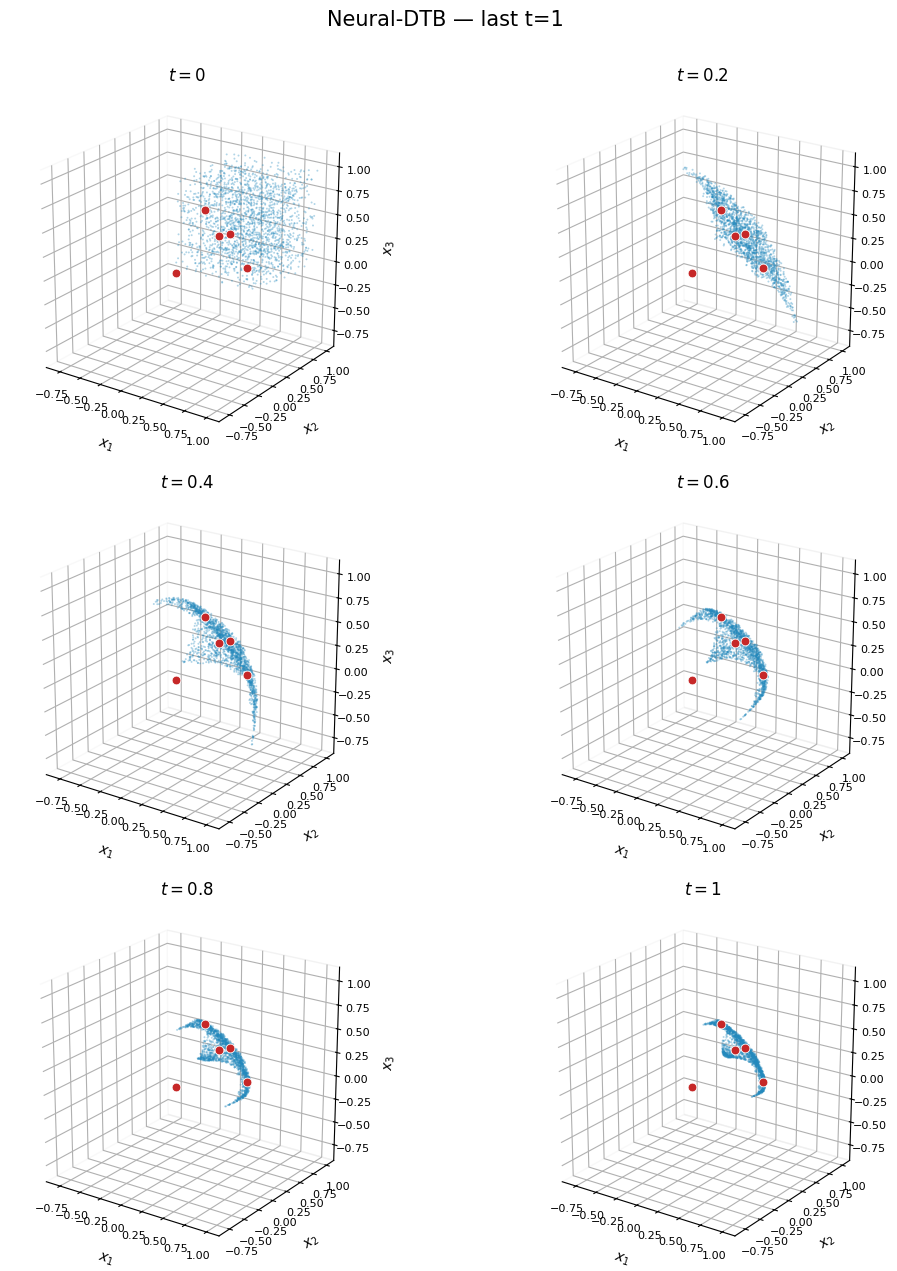

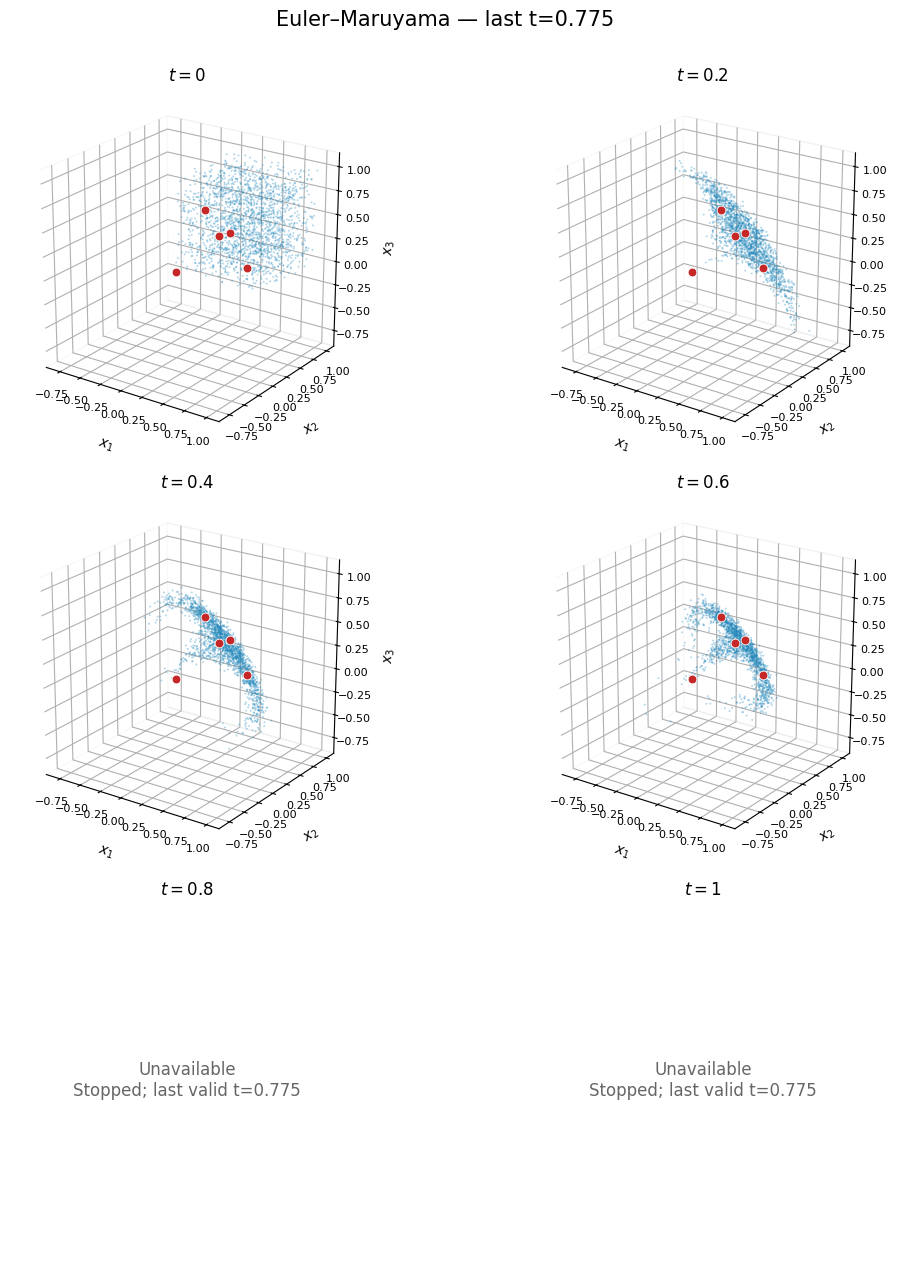

In [6]:
# BLOCK 5 — Compare completed/partial results only after the independent simulations.
runs = {'dtb': dtb_result, 'em': em_result}
if all(result is None for result in runs.values()):
    raise ValueError('Run at least one simulation cell before comparing snapshots.')
if not SNAPSHOT_TIMES or any(not np.isfinite(t) or t < 0 for t in SNAPSHOT_TIMES):
    raise ValueError('Snapshot times must be nonempty, finite, and nonnegative.')


def snapshot_index(result, requested_time):
    """Match physical time exactly (up to rounding), never interpolate or repeat a state."""
    if result is None:
        return None
    index = round(requested_time / result['step_size'])
    if 0 <= index < len(result['times']) and np.isclose(
        result['times'][index], requested_time, rtol=0, atol=1e-10,
    ):
        return index
    return None


def unavailable_reason(result, requested_time):
    if result is None:
        return 'Not run'
    if requested_time > result['last_valid_time'] + 1e-10:
        verb = 'Stopped' if result['status'] == 'stopped' else 'Ended'
        return f'Unavailable\n{verb}; last valid t={result["last_valid_time"]:.4g}'
    return 'Unavailable\nNot on this method\'s time grid'


snapshot_indices = {
    name: [snapshot_index(result, t) for t in SNAPSHOT_TIMES]
    for name, result in runs.items()
}
timing_lines = [
    '| Method | Status | Accepted / attempted steps | Last valid time | Compute total (s) | Mean attempt (ms) | Loop wall (s) |',
    '| :--- | :--- | ---: | ---: | ---: | ---: | ---: |',
]
for name, result in runs.items():
    if result is None:
        timing_lines.append(f'| {name.upper()} | not run | — | — | — | — | — |')
        continue
    timing_lines.append(
        f'| {result["method"]} | {result["status"]} | '
        f'{result["completed_steps"]} / {result["attempted_steps"]} | '
        f'{result["last_valid_time"]:.6g} | {result["compute_seconds"]:.6f} | '
        f'{1000 * result["mean_attempt_seconds"]:.6f} | {result["wall_seconds"]:.6f} |'
    )

# A raw total-time ratio is misleading when one run stops earlier.
# Find the latest accepted time lying on BOTH grids, including different step sizes.
common_timing = None
if dtb_result is not None and em_result is not None:
    for dtb_index in range(len(dtb_result['times']) - 1, 0, -1):
        common_time = float(dtb_result['times'][dtb_index])
        em_index = snapshot_index(em_result, common_time)
        if em_index is not None and em_index > 0:
            dtb_seconds = float(dtb_result['step_seconds'][:dtb_index].sum())
            em_seconds = float(em_result['step_seconds'][:em_index].sum())
            common_timing = {
                'final_time': common_time, 'dtb_steps': dtb_index, 'em_steps': em_index,
                'dtb_seconds': dtb_seconds, 'em_seconds': em_seconds,
                'dtb_over_em_ratio': dtb_seconds / em_seconds if em_seconds > 0 else None,
            }
            break
if common_timing is None:
    common_timing_text = 'No positive time has been completed on both grids; no timing ratio is reported.'
else:
    ratio = common_timing['dtb_over_em_ratio']
    ratio_text = f'{ratio:.2f}x' if ratio is not None else 'undefined (EM timer below resolution)'
    common_timing_text = (
        f'Common completed horizon: t={common_timing["final_time"]:.6g}. '
        f'DTB: {common_timing["dtb_steps"]} steps / {common_timing["dtb_seconds"]:.6f}s; '
        f'EM: {common_timing["em_steps"]} steps / {common_timing["em_seconds"]:.6f}s. '
        f'DTB / EM computation-time ratio: {ratio_text}. Failed attempts are excluded.'
    )
timing_table = '\n'.join(timing_lines)
display(Markdown('## Independent-run timing'))
display(Markdown(timing_table))
print(common_timing_text)
print(CONFIG['timing_scope'])
for result in runs.values():
    if result is not None and result['status'] == 'stopped':
        report_run(result)

availability_table = '\n'.join([
    '| Requested time | DTB | EM |', '| ---: | :--- | :--- |',
    *[
        f'| {t:.6g} | ' + ' | '.join(
            'available' if snapshot_indices[name][column] is not None
            else unavailable_reason(runs[name], t).replace('\n', ': ')
            for name in runs
        ) + ' |'
        for column, t in enumerate(SNAPSHOT_TIMES)
    ],
])
display(Markdown('## Snapshot availability'))
display(Markdown(availability_table))

output_dir = None
if SAVE_RUN:
    dtb_metadata = dtb_result['metadata'] if dtb_result is not None else {}
    output_dir = create_run_directory(
        EXPERIMENT_DIR / 'saved_runs', dim=DIM,
        network=dtb_metadata.get('network', NN_CHOICE),
        activation=dtb_metadata.get('activation', NN_ACTIVATION),
        width=dtb_metadata.get('width', MLP_WIDTH), depth=dtb_metadata.get('depth', MLP_DEPTH),
        parameter_count=dtb_metadata.get('trainable_parameters', 0),
        basis_size=dtb_metadata.get('basis_size', 0), seed=SEED,
    )


def plot_3d_cloud_snapshots(runs, snapshot_times, equilibria):
    """Separate matched grids; missing states get a notice instead of a point cloud."""
    references = np.asarray(equilibria)
    if references.shape != (len(EQUILIBRIUM_LABELS), 3) or not np.isfinite(references).all():
        raise ValueError('Each reference must have three finite coordinates and one label.')
    if not isinstance(PLOT_3D_COLUMNS, int) or PLOT_3D_COLUMNS < 1:
        raise ValueError('PLOT_3D_COLUMNS must be a positive integer.')
    if PLOT_3D_MAX_POINTS is not None and (
        not isinstance(PLOT_3D_MAX_POINTS, int) or PLOT_3D_MAX_POINTS < 1
    ):
        raise ValueError('PLOT_3D_MAX_POINTS must be None or a positive integer.')
    point_count = len(x_0)
    indices = np.arange(point_count)
    if PLOT_3D_MAX_POINTS is not None and PLOT_3D_MAX_POINTS < point_count:
        indices = np.sort(np.random.default_rng(SEED).choice(
            indices, size=PLOT_3D_MAX_POINTS, replace=False,
        ))
    values = [references.ravel()]
    for result in runs.values():
        if result is None:
            continue
        if result['particles'].shape != (len(result['times']), point_count, 3):
            raise ValueError('Each history needs its own time grid and the shared particle count.')
        if not np.isfinite(result['particles']).all():
            raise ValueError('Stored histories must contain only valid finite states.')
        for t in snapshot_times:
            index = snapshot_index(result, t)
            if index is not None:
                values.append(result['particles'][index].ravel())
    shown_values = np.concatenate(values)
    low, high = float(shown_values.min()), float(shown_values.max())
    padding = 0.08 * max(high - low, 1e-3)
    limits = (low - padding, high + padding)
    columns = min(PLOT_3D_COLUMNS, len(snapshot_times))
    rows = math.ceil(len(snapshot_times) / columns)
    figures = {}
    for name, result in runs.items():
        method = 'Neural-DTB' if name == 'dtb' else 'Euler–Maruyama'
        fig = plt.figure(figsize=(5.4 * columns, 4.2 * rows + 0.6))
        for panel, t in enumerate(snapshot_times, start=1):
            ax = fig.add_subplot(rows, columns, panel, projection='3d', computed_zorder=False)
            ax.set_title(rf'$t={t:.3g}$')
            index = snapshot_index(result, t)
            if index is None:
                ax.set_axis_off()
                ax.text2D(0.5, 0.5, unavailable_reason(result, t), transform=ax.transAxes,
                          ha='center', va='center', fontsize=12, color='#666666')
                continue
            points = result['particles'][index, indices]
            ax.scatter(
                points[:, 0], points[:, 1], points[:, 2],
                s=PLOT_3D_POINT_SIZE, alpha=PLOT_3D_ALPHA, color='#2389bd',
                edgecolors='none', depthshade=False, rasterized=True, zorder=2,
            )
            ax.scatter(
                references[:, 0], references[:, 1], references[:, 2],
                s=40, c='#c62828', marker='o', edgecolors='white',
                linewidths=0.6, depthshade=False, zorder=4,
            )
            ax.set(xlim=limits, ylim=limits, zlim=limits,
                   xlabel=r'$x_1$', ylabel=r'$x_2$', zlabel=r'$x_3$')
            ax.set_box_aspect((1, 1, 1))
            ax.view_init(elev=PLOT_3D_ELEV, azim=PLOT_3D_AZIM)
            ax.tick_params(labelsize=8, pad=1)
            for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
                axis.pane.fill = False
            ax.grid(True, alpha=0.2)
        last_time = 'not run' if result is None else f'last t={result["last_valid_time"]:.4g}'
        fig.suptitle(f'{method} — {last_time}', fontsize=15, y=0.985)
        fig.subplots_adjust(left=0.04, right=0.96, bottom=0.04, top=0.925,
                            wspace=0.08, hspace=0.15)
        figures[name] = fig
    return figures


cloud_3d_figures = plot_3d_cloud_snapshots(
    runs, SNAPSHOT_TIMES, KNOWN_EQUILIBRIA.detach().cpu().numpy(),
)
if output_dir is not None:
    for name, figure in cloud_3d_figures.items():
        figure.savefig(output_dir / f'{name}_3d_cloud_snapshots.png', dpi=180, bbox_inches='tight')
plt.show()


## Block 6 — Matched 2D snapshots, DTB diagnostics, and export

The coordinate plots show only requested snapshot times at or before EM's
last valid time, omitting later columns for both methods. If EM has not run,
all requested times remain available for the DTB plots. Tangent
diagnostics use only accepted DTB steps and are skipped if none exist.

With `SAVE_RUN=True`, save both figures and valid histories, **separate
`dtb_times` and `em_times` arrays**, per-attempt timings, stopping reasons,
and the last valid/failed times. Neither method must reach its full horizon
for comparison or export to work. If you rerun a simulation, rerun Blocks 5–6
to refresh the comparisons.


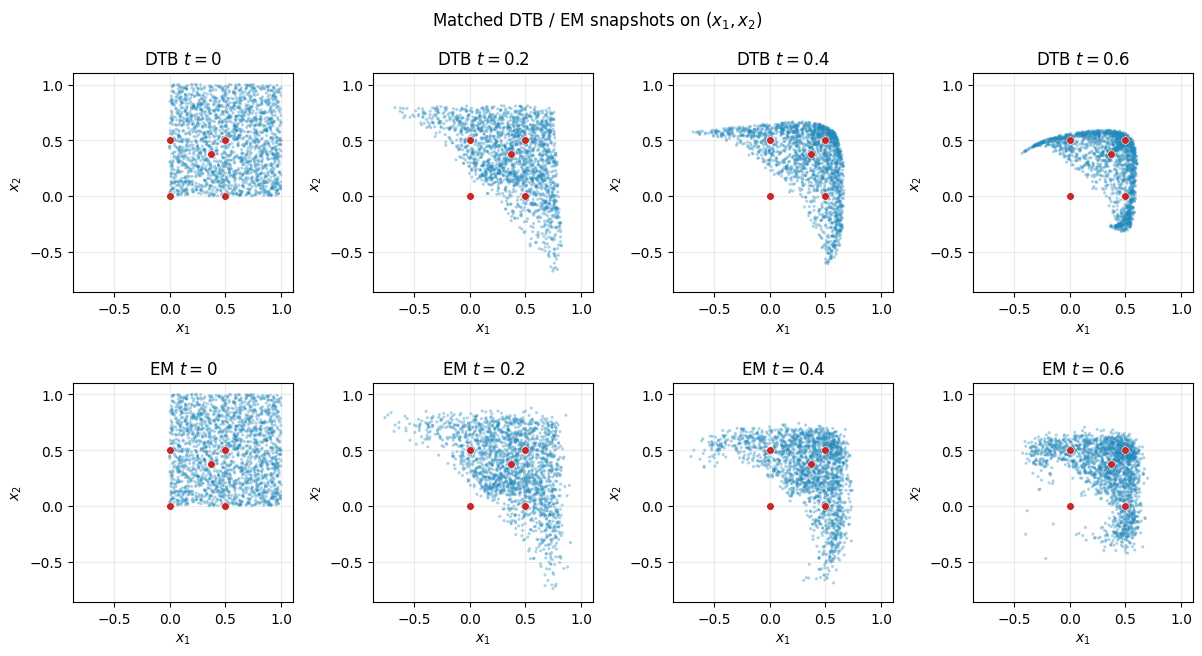

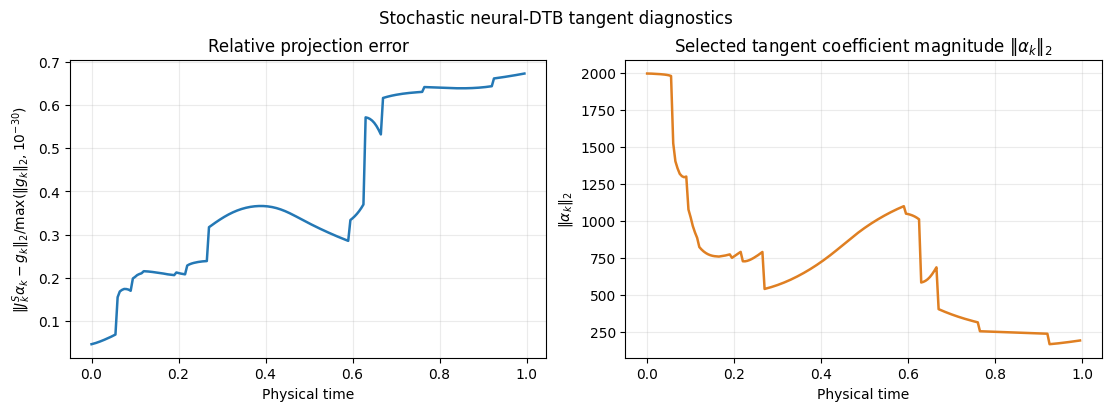

## Stochastic DTB diagnostics

| Metric | Mathematical definition | First | Mean | Final |
| :--- | :--- | ---: | ---: | ---: |
| Relative projection error | $r_k=\frac{\|J_k^S\alpha_k-g_k\|_2}{\max(\|g_k\|_2,10^{-30})}$ | 4.6297e-02 | 4.0303e-01 | 6.7262e-01 |
| Coefficient magnitude | $a_k=\|\alpha_k\|_2$ | 1.9931e+03 | 7.1370e+02 | 1.9146e+02 |
| Score RMS | $s_k=\sqrt{N^{-1}\sum_i\|q_i^k\|_2^2}$ | 0.0000e+00 | 1.0246e+01 | 2.8670e+01 |
| Diffusion correction RMS | $c_k=\frac{1}{2\sqrt N}\|Dq_k\|_2$ | 0.0000e+00 | 5.1229e-02 | 1.4335e-01 |
| Target velocity RMS | $v_k^g=N^{-1/2}\|g_k\|_2$ | 4.2830e+00 | 7.5497e-01 | 2.3463e-01 |
| Tangent velocity RMS | $v_k^u=N^{-1/2}\|u_k\|_2$ | 4.2784e+00 | 7.1003e-01 | 1.7363e-01 |

Saved valid histories, per-method times/status, figures, and timings to: /content/dtb-colab-experiments/DTB_Game_Ver2/saved_runs/cournot_3d_stochastic_mlp-tanh_w32_d4_p3395_basis128_seed2026_20260908T185021Z


In [7]:
# BLOCK 6 — Matched 2D snapshots, DTB diagnostics, and independent-history export.
snapshot_figures = {}
references = KNOWN_EQUILIBRIA.detach().cpu().numpy()
matched_snapshot_times = [
    t for t in SNAPSHOT_TIMES
    if em_result is None or t <= em_result['last_valid_time'] + 1e-10
]
matched_snapshot_indices = {
    name: [snapshot_index(result, t) for t in matched_snapshot_times]
    for name, result in runs.items()
}
if not matched_snapshot_times:
    print("No requested 2D snapshots at or before EM's last valid time.")
for first, second in COORDINATE_PAIRS:
    if first == second or not (1 <= first <= DIM and 1 <= second <= DIM):
        raise ValueError('Coordinate pairs use distinct one-based indices.')
    if not matched_snapshot_times:
        continue
    a, b = first - 1, second - 1
    values = [references[:, [a, b]]]
    for name, result in runs.items():
        for index in matched_snapshot_indices[name]:
            if index is not None:
                values.append(result['particles'][index][:, [a, b]])
    values = np.concatenate(values)
    low, high = float(values.min()), float(values.max())
    padding = 0.06 * max(high - low, 1e-3)
    limits = (low - padding, high + padding)
    figure, axes = plt.subplots(2, len(matched_snapshot_times), squeeze=False,
                               figsize=(3 * len(matched_snapshot_times), 6.5), constrained_layout=True)
    for row, (name, result) in enumerate(runs.items()):
        for column, t in enumerate(matched_snapshot_times):
            ax = axes[row, column]
            ax.set_title(rf'{name.upper()} $t={t:.3g}$')
            index = matched_snapshot_indices[name][column]
            if index is None:
                ax.set_axis_off()
                ax.text(0.5, 0.5, unavailable_reason(result, t), transform=ax.transAxes,
                        ha='center', va='center', fontsize=9, color='#666666')
                continue
            points = result['particles'][index]
            ax.scatter(points[:, a], points[:, b], s=5, alpha=0.38, color='#2389bd',
                       edgecolors='none', rasterized=True)
            ax.scatter(references[:, a], references[:, b], s=30, c='#c62828', marker='o',
                       edgecolors='white', linewidths=0.4, zorder=4)
            ax.set(xlim=limits, ylim=limits, xlabel=rf'$x_{{{first}}}$', ylabel=rf'$x_{{{second}}}$')
            ax.set_aspect('equal', adjustable='box')
            ax.grid(alpha=0.25)
    figure.suptitle(rf'Matched DTB / EM snapshots on $(x_{{{first}}},x_{{{second}}})$')
    if output_dir is not None:
        figure.savefig(output_dir / f'dtb_vs_em_x{first}_x{second}.png', dpi=180, bbox_inches='tight')
    snapshot_figures[(first, second)] = figure

records = [] if dtb_result is None else dtb_result['diagnostics']
relative_projection_errors = np.asarray([record['relative_projection_error'] for record in records])
alpha_norms = np.asarray([record['alpha_norm'] for record in records])
diagnostics_figure = None
if records:
    diagnostics_figure = plot_tangent_diagnostics(
        dtb_result['solve_times'], relative_projection_errors, alpha_norms,
        output_path=None if output_dir is None else output_dir / 'tangent_diagnostics.png',
    )
    metric_table = diagnostics_markdown(records)
else:
    metric_table = 'No accepted DTB steps: tangent diagnostics are unavailable.'
plt.show()
display(Markdown('## Stochastic DTB diagnostics'))
display(Markdown(metric_table))

if output_dir is not None:
    # A run's own time grid is saved alongside its (possibly shorter) valid history.
    arrays = {}
    summary_keys = (
        'method', 'step_size', 'requested_final_time', 'requested_steps', 'max_abs_state',
        'status', 'stop_reason', 'failed_step', 'failed_time', 'completed_steps',
        'attempted_steps', 'last_valid_time', 'compute_seconds', 'mean_attempt_seconds',
        'wall_seconds', 'metadata',
    )
    run_summaries = {}
    for name, result in runs.items():
        if result is None:
            run_summaries[name] = {'status': 'not run'}
            continue
        run_summaries[name] = {key: result[key] for key in summary_keys}
        arrays[f'{name}_times'] = result['times']
        arrays[f'{name}_particles'] = result['particles']
        arrays[f'{name}_step_seconds'] = result['step_seconds']
    if dtb_result is not None:
        arrays.update(
            solve_times=dtb_result['solve_times'], scores=dtb_result['scores'],
            log_density=dtb_result['log_density'], coefficients=dtb_result['coefficients'],
            selected_parameter_indices=np.asarray(dtb_result['metadata']['selected_parameter_indices']),
            relative_projection_error=relative_projection_errors, alpha_norm=alpha_norms,
        )
    saved_config = {
        **CONFIG, 'runs': run_summaries, 'common_horizon_timing': common_timing,
        'snapshot_times': list(SNAPSHOT_TIMES), 'save_run': True, 'output_dir': str(output_dir),
        'coordinate_pairs': [list(pair) for pair in COORDINATE_PAIRS],
        'plot_3d_columns': PLOT_3D_COLUMNS, 'plot_3d_max_points': PLOT_3D_MAX_POINTS,
        'plot_3d_elevation': PLOT_3D_ELEV, 'plot_3d_azimuth': PLOT_3D_AZIM,
        'plot_3d_point_size': PLOT_3D_POINT_SIZE, 'plot_3d_alpha': PLOT_3D_ALPHA,
    }
    stop_notes = '\n'.join(
        f'{result["method"]}: {result["stop_reason"]} (attempt {result["failed_step"]}, '
        f't={result["failed_time"]:.6g}; last valid t={result["last_valid_time"]:.6g}).'
        for result in runs.values() if result is not None and result['status'] == 'stopped'
    )
    save_run_data(
        output_dir, config=saved_config, arrays=arrays,
        metrics_markdown='\n\n'.join([
            timing_table, CONFIG['timing_scope'], common_timing_text, stop_notes,
            availability_table, metric_table,
        ]),
    )
    print('Saved valid histories, per-method times/status, figures, and timings to:', output_dir)
else:
    print('SAVE_RUN=False: results are available in dtb_result / em_result; no output folder created.')
